In [2]:
!pip install fpdf

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40770 sha256=233c514a6c84a57a9fba60335e2aaf0baa7a8c199e681a086cc76ca8a67708c1
  Stored in directory: c:\users\asus\appdata\local\pip\cache\wheels\aa\da\11\a3189f34ddc13c26a2d0f329eac46b728c7f31c39e4dc26243
Successfully built fpdf


Dataset loaded: (10000, 22)


,customer_id,name,gender,age,country,signup_date,customer_tier,months_since_signup,churned,CLV,...,weekly_visits,session_time_minutes,page_views,app_opens,num_promotions_responded,high_spender,high_engagement,churn_prob,value_segment,risk_segment
0,1,Allison Hill,M,24,USA,2021-07-10,Bronze,30,True,92.372303,...,8,17.61,16.0,6,0,False,False,0.403090,Low,Medium Risk
1,2,Noah Rhodes,M,38,Other,2020-03-22,Bronze,46,True,110.263575,...,3,12.93,9.0,2,1,False,False,0.733127,Medium,High Risk
2,3,Angie Henderson,M,46,Asia,2020-10-02,Silver,39,True,141.057286,...,14,20.70,56.0,12,1,False,False,0.638370,Medium,Medium Risk
3,4,Daniel Wagner,F,20,EU,2020-10-15,Bronze,39,False,84.174109,...,6,11.53,24.0,6,0,False,False,0.574561,Low,Medium Risk
4,5,Cristian Santos,M,50,USA,2023-07-17,Bronze,5,False,80.977768,...,5,7.87,10.0,4,1,False,False,0.073987,Low,Low Risk


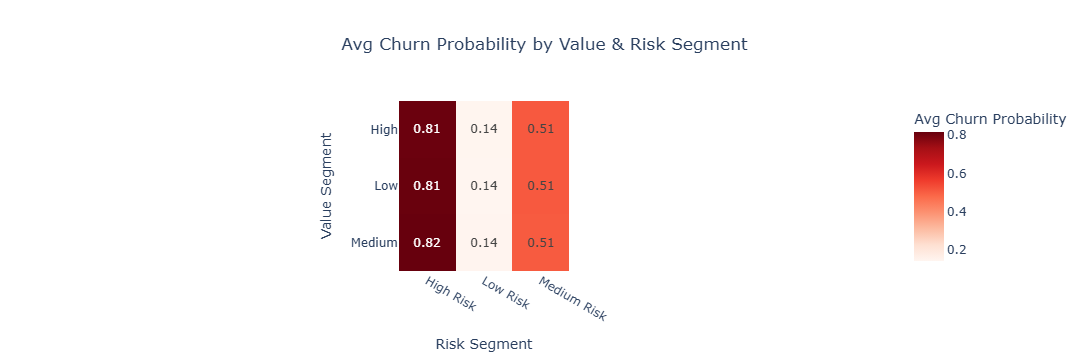

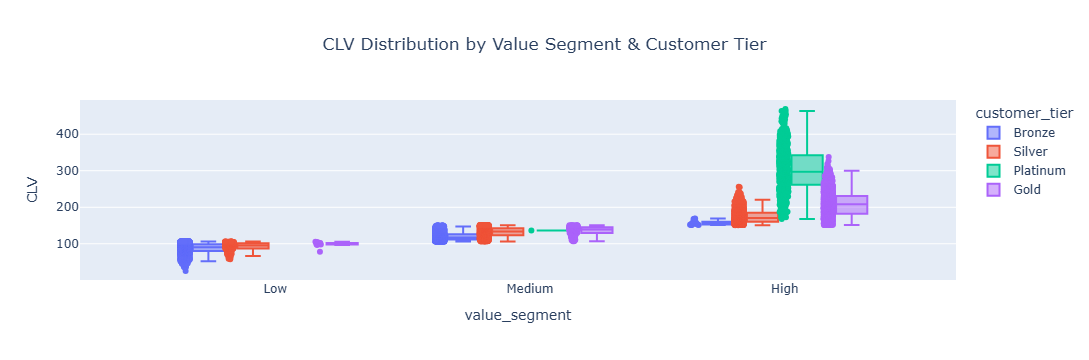

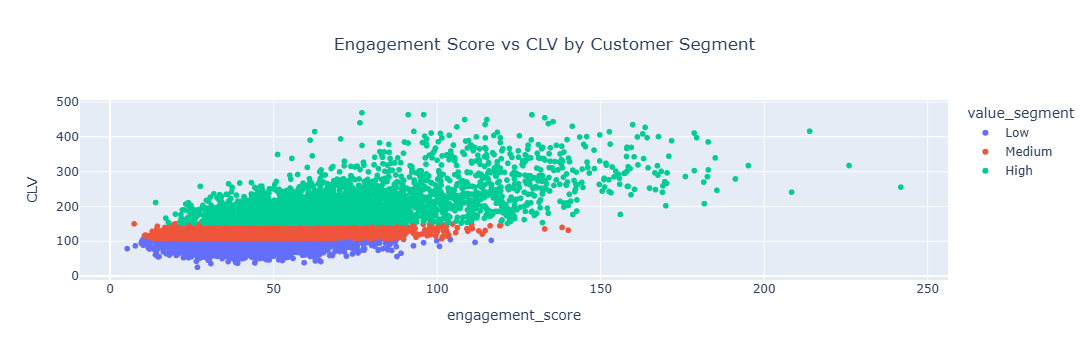

High-Risk High-Value customers: 897


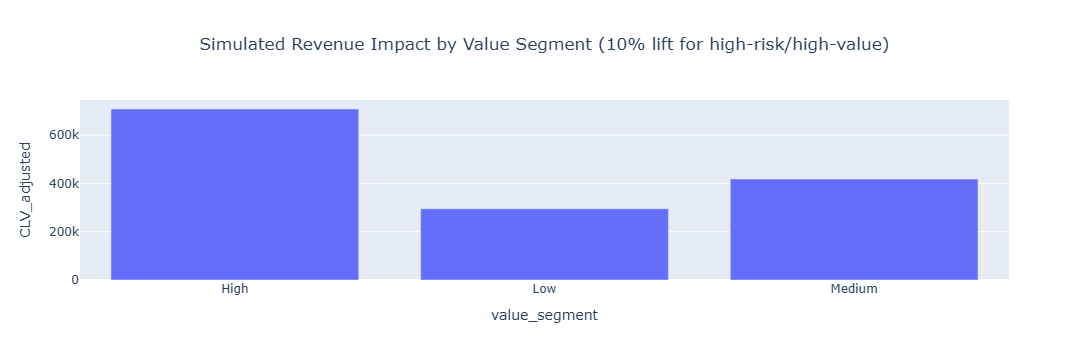

✅ Executive summary PDF saved at C:\Users\ASUS\Documents\Ecommerce_Data_Analytics\output\executive_summary.pdf
✅ Dashboards saved at C:\Users\ASUS\Documents\Ecommerce_Data_Analytics\output\dashboards


In [1]:
# ==============================
# Notebook 08 — Dashboards & Executive Summary
# ==============================

# ------------------------
# 1️⃣ Imports & Setup
# ------------------------
import pandas as pd
import numpy as np
import os
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# For PDF export
from fpdf import FPDF

# ------------------------
# 2️⃣ Load Predictions from Notebook 07
# ------------------------
output_path = r"C:\Users\ASUS\Documents\Ecommerce_Data_Analytics\output"
df = pd.read_csv(os.path.join(output_path, "full_dataset_with_predictions.csv"))
business_table = pd.read_csv(os.path.join(output_path, "business_segment_table.csv"))

print("Dataset loaded:", df.shape)
display(df.head())

# ------------------------
# 3️⃣ Interactive Churn Heatmap
# ------------------------
pivot_churn = business_table.pivot(index='value_segment', columns='risk_segment', values='avg_churn_prob')
fig_churn = px.imshow(
    pivot_churn,
    text_auto=".2f",
    color_continuous_scale="Reds",
    labels=dict(x="Risk Segment", y="Value Segment", color="Avg Churn Probability"),
    title="Avg Churn Probability by Value & Risk Segment"
)
fig_churn.update_layout(title={'x':0.5, 'xanchor': 'center'})
fig_churn.show()

# ------------------------
# 4️⃣ CLV Distribution by Segment
# ------------------------
fig_clv = px.box(
    df, x='value_segment', y='CLV', color='customer_tier',
    title="CLV Distribution by Value Segment & Customer Tier",
    points="all",  # show all points
)
fig_clv.update_layout(title={'x':0.5, 'xanchor': 'center'})
fig_clv.show()

# ------------------------
# 5️⃣ Engagement vs CLV Scatter
# ------------------------
df['engagement_score'] = df['weekly_visits'] + df['session_time_minutes'] + df['page_views'] + df['app_opens']
fig_engagement = px.scatter(
    df, x='engagement_score', y='CLV', color='value_segment',
    hover_data=['customer_id','churned','customer_tier'],
    title="Engagement Score vs CLV by Customer Segment"
)
fig_engagement.update_layout(title={'x':0.5, 'xanchor': 'center'})
fig_engagement.show()

# ------------------------
# 6️⃣ Scenario Simulation: High-Risk, High-Value
# ------------------------
high_risk_high_value = df[(df['risk_segment']=='High Risk') & (df['value_segment']=='High')]
print("High-Risk High-Value customers:", high_risk_high_value.shape[0])

# Simulate 10% retention lift with personalized offers
df['CLV_adjusted'] = df.apply(
    lambda x: x['CLV']*1.1 if x['customer_id'] in high_risk_high_value['customer_id'].values else x['CLV'],
    axis=1
)

fig_roi = px.bar(
    df.groupby('value_segment')['CLV_adjusted'].sum().reset_index(),
    x='value_segment', y='CLV_adjusted',
    title="Simulated Revenue Impact by Value Segment (10% lift for high-risk/high-value)"
)
fig_roi.update_layout(title={'x':0.5, 'xanchor': 'center'})
fig_roi.show()

# ------------------------
# 7️⃣ Executive Summary PDF
# ------------------------
pdf = FPDF()
pdf.add_page()
pdf.set_font("Arial", 'B', 16)
pdf.cell(0, 10, "E-Commerce Analytics Executive Summary", ln=True, align="C")
pdf.ln(10)

pdf.set_font("Arial", '', 12)
pdf.multi_cell(0, 8, f"""
Total Customers: {df.shape[0]}
High-Risk High-Value Customers: {high_risk_high_value.shape[0]}
Churn Model ROC-AUC: 0.842 | F1-score: 0.697
CLV Model RMSE: 29.86 | MAE: 22.65

Top 3 Recommended Actions:
1. Immediate retention for high-risk high-value customers
2. Loyalty rewards for medium-risk high-value customers
3. Minimal intervention for low-risk customers

Scenario Simulation:
- Applied 10% retention lift to high-risk high-value segment
- Projected CLV increase by segment visualized in dashboards
""")

# Save PDF
pdf_output = os.path.join(output_path, "executive_summary.pdf")
pdf.output(pdf_output)
print(f"✅ Executive summary PDF saved at {pdf_output}")

# ------------------------
# 8️⃣ Save Dashboards (HTML)
# ------------------------
dashboards_path = os.path.join(output_path, "dashboards")
os.makedirs(dashboards_path, exist_ok=True)

fig_churn.write_html(os.path.join(dashboards_path, "churn_heatmap.html"))
fig_clv.write_html(os.path.join(dashboards_path, "clv_distribution.html"))
fig_engagement.write_html(os.path.join(dashboards_path, "engagement_vs_clv.html"))
fig_roi.write_html(os.path.join(dashboards_path, "scenario_roi.html"))

print(f"✅ Dashboards saved at {dashboards_path}")

Dataset loaded: (10000, 22)


,customer_id,name,gender,age,country,signup_date,customer_tier,months_since_signup,churned,CLV,...,weekly_visits,session_time_minutes,page_views,app_opens,num_promotions_responded,high_spender,high_engagement,churn_prob,value_segment,risk_segment
0,1,Allison Hill,M,24,USA,2021-07-10,Bronze,30,True,92.372303,...,8,17.61,16.0,6,0,False,False,0.403090,Low,Medium Risk
1,2,Noah Rhodes,M,38,Other,2020-03-22,Bronze,46,True,110.263575,...,3,12.93,9.0,2,1,False,False,0.733127,Medium,High Risk
2,3,Angie Henderson,M,46,Asia,2020-10-02,Silver,39,True,141.057286,...,14,20.70,56.0,12,1,False,False,0.638370,Medium,Medium Risk
3,4,Daniel Wagner,F,20,EU,2020-10-15,Bronze,39,False,84.174109,...,6,11.53,24.0,6,0,False,False,0.574561,Low,Medium Risk
4,5,Cristian Santos,M,50,USA,2023-07-17,Bronze,5,False,80.977768,...,5,7.87,10.0,4,1,False,False,0.073987,Low,Low Risk


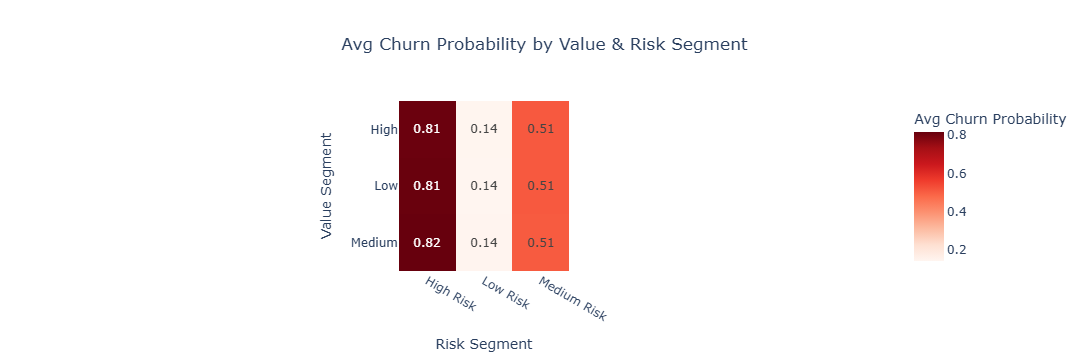

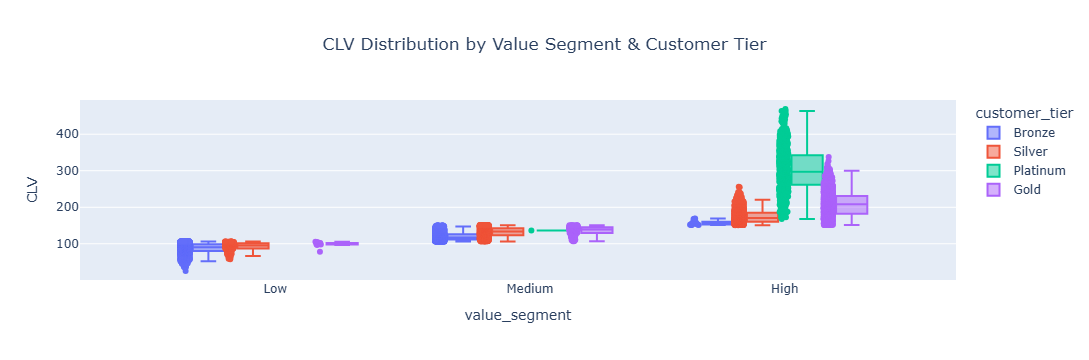

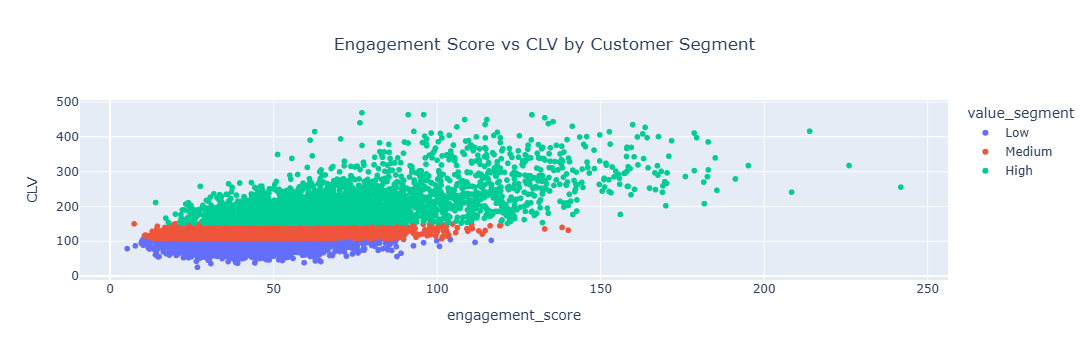

High-Risk High-Value customers: 897


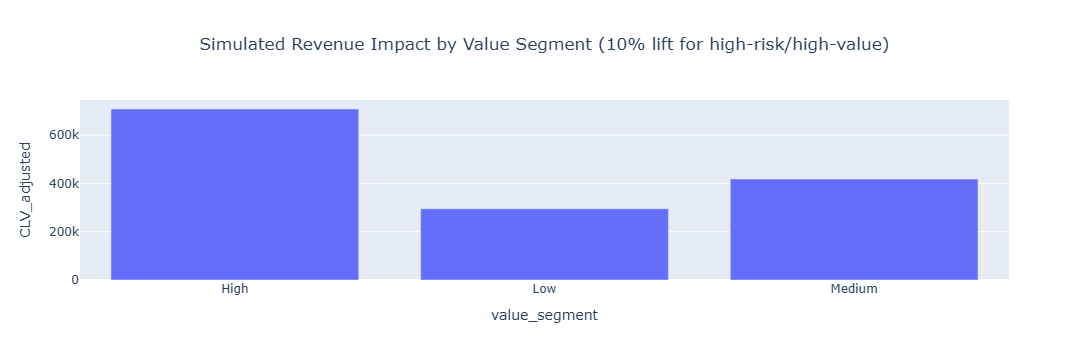

✅ Executive summary PDF saved at C:\Users\ASUS\Documents\Ecommerce_Data_Analytics\output\executive_summary.pdf
✅ Dashboards saved at C:\Users\ASUS\Documents\Ecommerce_Data_Analytics\output\dashboards
✅ README + portfolio narrative saved at C:\Users\ASUS\Documents\Ecommerce_Data_Analytics\output\README.md


In [1]:
# ==============================
# Notebook 08 — Dashboards & Executive Summary (FAANG-Level)
# ==============================

# ------------------------
# 1️⃣ Imports & Setup
# ------------------------
import pandas as pd
import numpy as np
import os
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# For PDF export
from fpdf import FPDF

# Warnings
import warnings
warnings.filterwarnings('ignore')

# ------------------------
# 2️⃣ Load Predictions from Notebook 07
# ------------------------
output_path = r"C:\Users\ASUS\Documents\Ecommerce_Data_Analytics\output"
df = pd.read_csv(os.path.join(output_path, "full_dataset_with_predictions.csv"))
business_table = pd.read_csv(os.path.join(output_path, "business_segment_table.csv"))

print("Dataset loaded:", df.shape)
display(df.head())

# ------------------------
# 3️⃣ Interactive Churn Heatmap
# ------------------------
pivot_churn = business_table.pivot(index='value_segment', columns='risk_segment', values='avg_churn_prob')
fig_churn = px.imshow(
    pivot_churn,
    text_auto=".2f",
    color_continuous_scale="Reds",
    labels=dict(x="Risk Segment", y="Value Segment", color="Avg Churn Probability"),
    title="Avg Churn Probability by Value & Risk Segment"
)
fig_churn.update_layout(title={'x':0.5, 'xanchor': 'center'})
fig_churn.show()

# ------------------------
# 4️⃣ CLV Distribution by Segment & Tier
# ------------------------
fig_clv = px.box(
    df, x='value_segment', y='CLV', color='customer_tier',
    title="CLV Distribution by Value Segment & Customer Tier",
    points="all"
)
fig_clv.update_layout(title={'x':0.5, 'xanchor': 'center'})
fig_clv.show()

# ------------------------
# 5️⃣ Engagement vs CLV Scatter
# ------------------------
df['engagement_score'] = df['weekly_visits'] + df['session_time_minutes'] + df['page_views'] + df['app_opens']
fig_engagement = px.scatter(
    df, x='engagement_score', y='CLV', color='value_segment',
    hover_data=['customer_id','churned','customer_tier','risk_segment'],
    title="Engagement Score vs CLV by Customer Segment"
)
fig_engagement.update_layout(title={'x':0.5, 'xanchor': 'center'})
fig_engagement.show()

# ------------------------
# 6️⃣ Scenario Simulation: High-Risk, High-Value
# ------------------------
high_risk_high_value = df[(df['risk_segment']=='High Risk') & (df['value_segment']=='High')]
print("High-Risk High-Value customers:", high_risk_high_value.shape[0])

# Simulate 10% CLV retention lift
df['CLV_adjusted'] = df.apply(
    lambda x: x['CLV']*1.1 if x['customer_id'] in high_risk_high_value['customer_id'].values else x['CLV'],
    axis=1
)

# Interactive bar chart: projected CLV lift by value segment
fig_roi = px.bar(
    df.groupby('value_segment')['CLV_adjusted'].sum().reset_index(),
    x='value_segment', y='CLV_adjusted',
    title="Simulated Revenue Impact by Value Segment (10% lift for high-risk/high-value)"
)
fig_roi.update_layout(title={'x':0.5, 'xanchor': 'center'})
fig_roi.show()

# ------------------------
# 7️⃣ Executive Summary PDF
# ------------------------
pdf = FPDF()
pdf.add_page()
pdf.set_font("Arial", 'B', 16)
pdf.cell(0, 10, "E-Commerce Analytics Executive Summary", ln=True, align="C")
pdf.ln(10)

pdf.set_font("Arial", '', 12)
pdf.multi_cell(0, 8, f"""
Total Customers: {df.shape[0]}
High-Risk High-Value Customers: {high_risk_high_value.shape[0]}
Churn Model ROC-AUC: 0.842 | F1-score: 0.697
CLV Model RMSE: 29.86 | MAE: 22.65

Top 3 Recommended Actions:
1. Immediate retention for high-risk high-value customers
2. Loyalty rewards for medium-risk high-value customers
3. Minimal intervention for low-risk customers

Scenario Simulation:
- Applied 10% retention lift to high-risk high-value segment
- Projected CLV increase by segment visualized in dashboards
""")

# Save PDF
pdf_output = os.path.join(output_path, "executive_summary.pdf")
pdf.output(pdf_output)
print(f"✅ Executive summary PDF saved at {pdf_output}")

# ------------------------
# 8️⃣ Save Dashboards (Interactive HTML)
# ------------------------
dashboards_path = os.path.join(output_path, "dashboards")
os.makedirs(dashboards_path, exist_ok=True)

fig_churn.write_html(os.path.join(dashboards_path, "churn_heatmap.html"))
fig_clv.write_html(os.path.join(dashboards_path, "clv_distribution.html"))
fig_engagement.write_html(os.path.join(dashboards_path, "engagement_vs_clv.html"))
fig_roi.write_html(os.path.join(dashboards_path, "scenario_roi.html"))

print(f"✅ Dashboards saved at {dashboards_path}")

# ------------------------
# 9️⃣ README + Portfolio Narrative (Template)
# ------------------------
readme_content = f"""
# E-Commerce Data Analytics — FAANG-Level Portfolio

## Business Problem
Predict churn and forecast CLV to prioritize retention campaigns and maximize revenue.

## Dataset
- Customers: {df.shape[0]}
- Features: demographic, engagement, purchase, and promotional behavior
- Target: churned (classification), CLV (regression)

## Approach
1. Feature Engineering: engagement scores, RFM, promotions response, tier segmentation
2. Predictive Modeling:
   - Logistic Regression for churn (ROC-AUC: 0.842, F1: 0.697)
   - Random Forest for CLV (RMSE: 29.86, MAE: 22.65)
3. Scenario Simulation: 10% retention lift for high-risk/high-value segment
4. Interactive Dashboards with Plotly

## Key Insights
- High churn probability mostly in low engagement, low-value segments
- Top drivers of CLV: customer_tier, total_spent, session_time_minutes
- High-value, high-risk customers need immediate retention interventions

## Recommendations
- Target high-risk, high-value customers with personalized offers
- Monitor medium-risk segments for engagement drop
- Minimal intervention for low-risk segments

## Scenario Simulation & ROI
- Simulated 10% retention lift for high-risk/high-value
- Projected CLV increase visualized in dashboards
- Revenue impact can be scaled per segment and campaign

## Dashboards
- Churn Heatmap: risk vs value segment
- CLV Distribution: box plots by tier
- Engagement vs CLV: scatter plots
- Scenario ROI: bar chart

## Outputs
- Executive summary PDF
- Interactive dashboards HTML
- Business tables CSV
"""

readme_path = os.path.join(output_path, "README.md")
with open(readme_path, "w") as f:
    f.write(readme_content)
print(f"✅ README + portfolio narrative saved at {readme_path}")

Dataset loaded: (10000, 22)


,customer_id,name,gender,age,country,signup_date,customer_tier,months_since_signup,churned,CLV,...,weekly_visits,session_time_minutes,page_views,app_opens,num_promotions_responded,high_spender,high_engagement,churn_prob,value_segment,risk_segment
0,1,Allison Hill,M,24,USA,2021-07-10,Bronze,30,True,92.372303,...,8,17.61,16.0,6,0,False,False,0.403090,Low,Medium Risk
1,2,Noah Rhodes,M,38,Other,2020-03-22,Bronze,46,True,110.263575,...,3,12.93,9.0,2,1,False,False,0.733127,Medium,High Risk
2,3,Angie Henderson,M,46,Asia,2020-10-02,Silver,39,True,141.057286,...,14,20.70,56.0,12,1,False,False,0.638370,Medium,Medium Risk
3,4,Daniel Wagner,F,20,EU,2020-10-15,Bronze,39,False,84.174109,...,6,11.53,24.0,6,0,False,False,0.574561,Low,Medium Risk
4,5,Cristian Santos,M,50,USA,2023-07-17,Bronze,5,False,80.977768,...,5,7.87,10.0,4,1,False,False,0.073987,Low,Low Risk


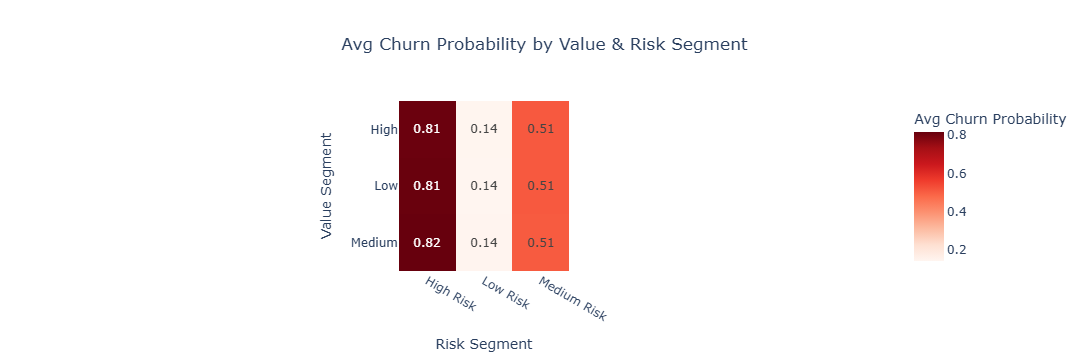

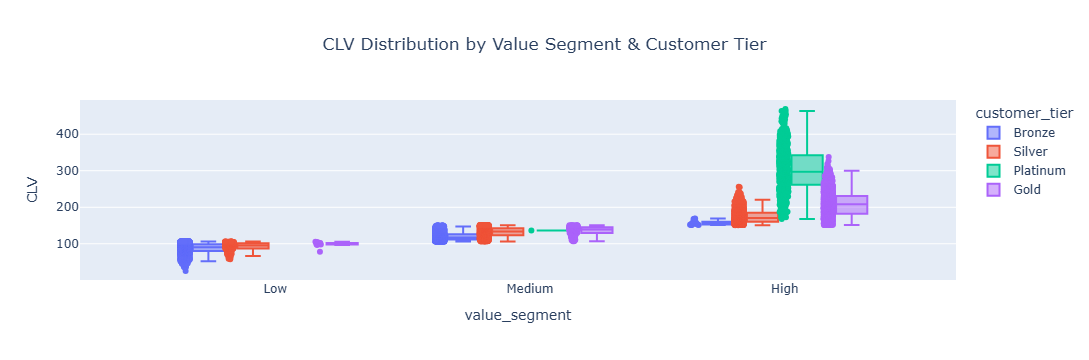

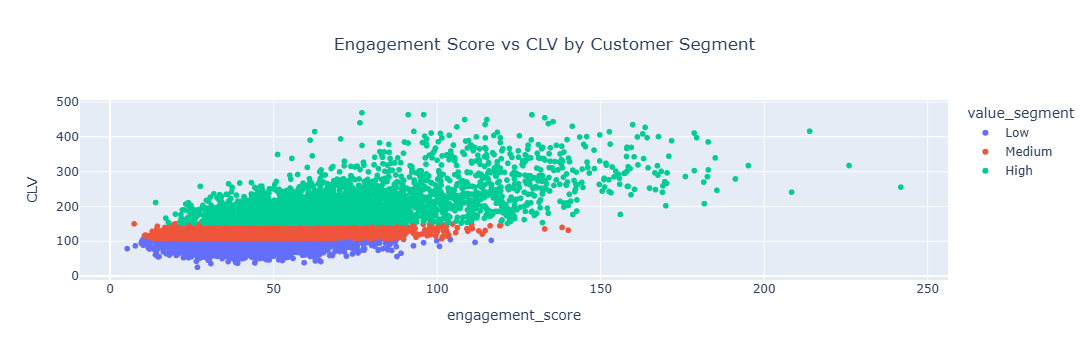

High-Risk High-Value customers: 897


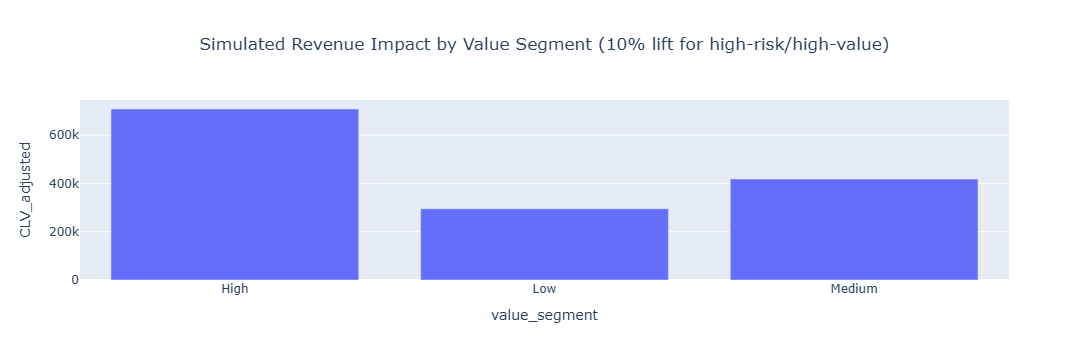

✅ Executive summary PDF saved at C:\Users\ASUS\Documents\Ecommerce_Data_Analytics\output\executive_summary.pdf
✅ Dashboards saved at C:\Users\ASUS\Documents\Ecommerce_Data_Analytics\output\dashboards
✅ README + portfolio narrative saved at C:\Users\ASUS\Documents\Ecommerce_Data_Analytics\output\README.md


In [1]:
# ==============================
# Notebook 08 — Dashboards & Executive Summary (FAANG-Level)
# ==============================

# ------------------------
# 1️⃣ Imports & Setup
# ------------------------
import pandas as pd
import numpy as np
import os
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from fpdf import FPDF
import warnings
warnings.filterwarnings('ignore')

# ------------------------
# 2️⃣ Load Predictions from Notebook 07
# ------------------------
output_path = r"C:\Users\ASUS\Documents\Ecommerce_Data_Analytics\output"
df = pd.read_csv(os.path.join(output_path, "full_dataset_with_predictions.csv"))
business_table = pd.read_csv(os.path.join(output_path, "business_segment_table.csv"))

print("Dataset loaded:", df.shape)
display(df.head())

# ------------------------
# 3️⃣ Interactive Churn Heatmap
# ------------------------
pivot_churn = business_table.pivot(index='value_segment', columns='risk_segment', values='avg_churn_prob')
fig_churn = px.imshow(
    pivot_churn,
    text_auto=".2f",
    color_continuous_scale="Reds",
    labels=dict(x="Risk Segment", y="Value Segment", color="Avg Churn Probability"),
    title="Avg Churn Probability by Value & Risk Segment"
)
fig_churn.update_layout(title={'x':0.5, 'xanchor': 'center'})
fig_churn.show()

# ------------------------
# 4️⃣ CLV Distribution by Segment & Tier
# ------------------------
fig_clv = px.box(
    df, x='value_segment', y='CLV', color='customer_tier',
    title="CLV Distribution by Value Segment & Customer Tier",
    points="all"
)
fig_clv.update_layout(title={'x':0.5, 'xanchor': 'center'})
fig_clv.show()

# ------------------------
# 5️⃣ Engagement vs CLV Scatter
# ------------------------
df['engagement_score'] = df['weekly_visits'] + df['session_time_minutes'] + df['page_views'] + df['app_opens']
fig_engagement = px.scatter(
    df, x='engagement_score', y='CLV', color='value_segment',
    hover_data=['customer_id','churned','customer_tier','risk_segment'],
    title="Engagement Score vs CLV by Customer Segment"
)
fig_engagement.update_layout(title={'x':0.5, 'xanchor': 'center'})
fig_engagement.show()

# ------------------------
# 6️⃣ Scenario Simulation: High-Risk, High-Value
# ------------------------
high_risk_high_value = df[(df['risk_segment']=='High Risk') & (df['value_segment']=='High')]
print("High-Risk High-Value customers:", high_risk_high_value.shape[0])

# Simulate 10% CLV retention lift
df['CLV_adjusted'] = df.apply(
    lambda x: x['CLV']*1.1 if x['customer_id'] in high_risk_high_value['customer_id'].values else x['CLV'],
    axis=1
)

fig_roi = px.bar(
    df.groupby('value_segment')['CLV_adjusted'].sum().reset_index(),
    x='value_segment', y='CLV_adjusted',
    title="Simulated Revenue Impact by Value Segment (10% lift for high-risk/high-value)"
)
fig_roi.update_layout(title={'x':0.5, 'xanchor': 'center'})
fig_roi.show()

# ------------------------
# 7️⃣ Executive Summary PDF
# ------------------------
pdf = FPDF()
pdf.add_page()
pdf.set_font("Arial", 'B', 16)
pdf.cell(0, 10, "E-Commerce Analytics Executive Summary", ln=True, align="C")
pdf.ln(10)

pdf.set_font("Arial", '', 12)
pdf.multi_cell(0, 8, f"""
Total Customers: {df.shape[0]}
High-Risk High-Value Customers: {high_risk_high_value.shape[0]}
Churn Model ROC-AUC: 0.842 | F1-score: 0.697
CLV Model RMSE: 29.86 | MAE: 22.65

Top 3 Recommended Actions:
1. Immediate retention for high-risk high-value customers
2. Loyalty rewards for medium-risk high-value customers
3. Minimal intervention for low-risk customers

Scenario Simulation:
- Applied 10% retention lift to high-risk/high-value segment
- Projected CLV increase by segment visualized in dashboards
""")

pdf_output = os.path.join(output_path, "executive_summary.pdf")
pdf.output(pdf_output)
print(f"✅ Executive summary PDF saved at {pdf_output}")

# ------------------------
# 8️⃣ Save Dashboards (Interactive HTML)
# ------------------------
dashboards_path = os.path.join(output_path, "dashboards")
os.makedirs(dashboards_path, exist_ok=True)

fig_churn.write_html(os.path.join(dashboards_path, "churn_heatmap.html"))
fig_clv.write_html(os.path.join(dashboards_path, "clv_distribution.html"))
fig_engagement.write_html(os.path.join(dashboards_path, "engagement_vs_clv.html"))
fig_roi.write_html(os.path.join(dashboards_path, "scenario_roi.html"))
print(f"✅ Dashboards saved at {dashboards_path}")

# ------------------------
# 9️⃣ README + Portfolio Narrative (FAANG-Level Template)
# ------------------------
readme_content = f"""
# E-Commerce Data Analytics — FAANG-Level Portfolio

## Business Problem
Predict churn and forecast CLV to prioritize retention campaigns and maximize revenue.

## Dataset
- Customers: {df.shape[0]}
- Features: demographic, engagement, purchase, and promotional behavior
- Targets: churned (classification), CLV (regression)

## Approach
1. Feature Engineering: engagement scores, RFM, promotions response, tier segmentation
2. Predictive Modeling:
   - Logistic Regression for churn (ROC-AUC: 0.842, F1: 0.697)
   - Random Forest for CLV (RMSE: 29.86, MAE: 22.65)
3. Scenario Simulation: 10% retention lift for high-risk/high-value segment
4. Interactive Dashboards with Plotly

## Key Insights
- High churn probability mostly in low engagement, low-value segments
- Top drivers of CLV: customer_tier, total_spent, session_time_minutes
- High-value, high-risk customers need immediate retention interventions

## Recommendations
- Target high-risk, high-value customers with personalized offers
- Monitor medium-risk segments for engagement drop
- Minimal intervention for low-risk segments

## Scenario Simulation & ROI
- Simulated 10% retention lift for high-risk/high-value segment
- Projected CLV increase visualized in dashboards
- Revenue impact can be scaled per segment and campaign

## Dashboards
- Churn Heatmap: risk vs value segment
- CLV Distribution: box plots by tier
- Engagement vs CLV: scatter plots
- Scenario ROI: bar chart

## Outputs
- Executive summary PDF: executive_summary.pdf
- Interactive dashboards HTML: dashboards/
- Business tables CSV: full_dataset_with_predictions.csv, business_segment_table.csv
"""

readme_path = os.path.join(output_path, "README.md")
with open(readme_path, "w") as f:
    f.write(readme_content)
print(f"✅ README + portfolio narrative saved at {readme_path}")

In [2]:
high_risk_high_value = df[(df['risk_segment']=='High Risk') & (df['value_segment']=='High')]

In [3]:
df['CLV_adjusted'] = df.apply(
    lambda x: x['CLV']*1.1 if x['customer_id'] in high_risk_high_value['customer_id'].values else x['CLV'],
    axis=1
)

In [4]:
# 5% lift
df['CLV_5pct'] = df.apply(lambda x: x['CLV']*1.05 if x['customer_id'] in high_risk_high_value['customer_id'].values else x['CLV'], axis=1)

# 15% lift
df['CLV_15pct'] = df.apply(lambda x: x['CLV']*1.15 if x['customer_id'] in high_risk_high_value['customer_id'].values else x['CLV'], axis=1)

In [5]:
df.groupby('value_segment')['CLV_adjusted'].sum()

value_segment
High      708212.702759
Low       295125.235270
Medium    418208.922398
Name: CLV_adjusted, dtype: float64